# What is a CNN ?

CNNs try to capture the spatial relationships in data. These are ideally suited for capturing patterns in images since images have spatial relationships in those pixels that are in the same vicinity contribute to making sense of the object.

**Understanding convolutions**

Images are described using pixels. These pixels can have varying values, depending on whether the image is black and white, grayscale, or color. The values in the pixels are reflective of the patterns they might be carrying. As part of convolution, we try and slide (perform a dot product) what we call filters across the image so as to capture patterns from the pixels.

## 1. What is an Image to a Computer?

A computer does not see a picture of a cat or a dog. It only sees numbers grid. This grid is called a **Matrix**.
* Each cell in the grid is a **Pixel**.
* The number inside represents the **Brightness** or intensity of that pixel.

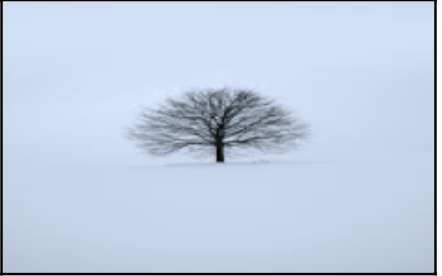

Your text provides a `4x4` image matrix. Let's lay it out cleanly so you can see it:


| (Row, Col) | Col 1 | Col 2 | Col 3 | Col 4 |
| :--- | :---: | :---: | :---: | :---: |
| **Row 1** | 6 | 1 | 4 | 3 |
| **Row 2** | 8 | 6 | 7 | 9 |
| **Row 3** | 4 | 3 | 2 | 7 |
| **Row 4** | 1 | 3 | 5 | 4 |

---

## 2. What is a Filter (Kernel)?

A **Filter** (also called a **Kernel**) is just a smaller grid of numbers. Think of it like a magnifying glass with a pattern painted on it.

Your text gives a `3x3` filter with these 9 numbers: `1, 0, -1, 1, 0, -1, 1, 0, -1`. Arranged as a grid, it looks like this:


| | Col 1 | Col 2 | Col 3 |
| :--- | :---: | :---: | :---: |
| **Row 1** | 1 | 0 | -1 |
| **Row 2** | 1 | 0 | -1 |
| **Row 3** | 1 | 0 | -1 |

**What is this filter doing?** 
Notice how the left column is positive numbers (`1`), and the right column is negative numbers (`-1`). This specific arrangement is designed to detect **vertical edges** (where a bright area meets a dark area) in a photo.

---

## 3. How the Process Works (Sliding & Multiplying)

To apply the filter, we place our `3x3` "magnifying glass" over the top-left corner of our `4x4` image.

### Step A: Finding the First Number (5)
We align the `3x3` filter over **Rows 1 to 3** and **Columns 1 to 3** of the image. Now, we multiply the overlapping numbers directly against each other (element-wise multiplication) and add all the results together:

```text
  (6 *  1)  +  (1 * 0)  +  (4 * -1)   <-- Row 1 overlap
+ (8 *  1)  +  (6 * 0)  +  (7 * -1)   <-- Row 2 overlap
+ (4 *  1)  +  (3 * 0)  +  (2 * -1)   <-- Row 3 overlap
-----------------------------------
=    6      +     0     -     4       =  2
+    8      +     0     -     7       =  1
+    4      +     0     -     2       =  2
-----------------------------------
Total Sum = 2 + 1 + 2 = 5
```

This gives us `5`, which is the top-left value of our final output map!

### Step B: Slide Right to find the Second Number (-9)
Next, we slide our `3x3` filter one pixel to the right. It now covers **Rows 1 to 3** and **Columns 2 to 4**. Let's do the exact same multiplication math with the new overlapping numbers:

```text
  (1 *  1)  +  (4 * 0)  +  (3 * -1)   =  -2
+ (6 *  1)  +  (7 * 0)  +  (9 * -1)   =  -3
+ (3 *  1)  +  (2 * 0)  +  (7 * -1)   =  -4
-----------------------------------
Total Sum = (-2) + (-3) + (-4) = -9
```

This gives us `-9`, the top-right value of our output map.

### Step C: Slide Down
After hitting the right wall, we slide the filter back to the left, but move it down one row. We repeat the math to find the bottom two numbers (`-1` and `-8`).

---

## 4. The Final Output

By sliding the filter across all possible spaces, our original `4x4` image shrinks down into a `2x2` output matrix:


| | Col 1 | Col 2 |
| :--- | :---: | :---: |
| **Top** | 5 | -9 |
| **Bottom** | -1 | -8 |

### Why did the size shrink?
Because a `3x3` filter cannot center itself on the absolute outer edge pixels without falling off the grid.

The mathematical formula to predict the output size is:

$$\text{Output Size} = (n - f + 1) \times (n - f + 1)$$

* $n$ is the image width/height (`4`)
* $f$ is the filter width/height (`3`)

**Math:** $(4 - 3 + 1) = 2$. So the output is a `2x2` grid.


#### Outcome observation 

When you slide a $3 \times 3$ filter across a $4 \times 4$ image, the filter only has enough room to make **4 steps total** ($1\times1$, $1\times2$, $2\times1$, and $2\times2$).

Because of this, the filter behaves unfairly to different parts of your photo:
* **The Middle Pixels get lots of attention:** The pixels in the center of the image are overlapped by the filter multiple times during different steps.
* **The Edge Pixels are neglected:** The pixels on the very outer edges (especially the last column and last row) are barely touched.

---

#### Why This is a Big Problem for AI

If a very important feature—like a vertical edge, a line, or part of an object—happens to be located on the far right border of your photo, the AI will likely miss it or miscalculate it.

The network is being fed less information about the borders of the image compared to the center. Every time you apply a filter without a fix, your image shrinks, and you "shave off" the outer borders of your data.

---

#### The Solution: How We Fix It

To enable the network to capture this missing border information, we use a technique called **Padding** (specifically, *Same Padding* or *Zero Padding*).

Instead of letting the image shrink, we wrap the original $4 \times 4$ image in a "buffer zone" of extra pixels (usually filled with zeros).

##### Visualizing Padding
By adding a border of `0`s around our original $4 \times 4$ matrix, we turn it into a larger $6 \times 6$ matrix:


| | | | | | |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **0** | **0** | **0** | **0** | **0** | **0** |
| **0** | 6 | 1 | 4 | 3 | **0** |
| **0** | 8 | 6 | 7 | 9 | **0** |
| **0** | 4 | 3 | 2 | 7 | **0** |
| **0** | 1 | 3 | 5 | 4 | **0** |
| **0** | **0** | **0** | **0** | **0** | **0** |

### Why Padding Solves the Problem:
* **No Data Loss:** Now, the $3 \times 3$ filter can safely center itself directly over the original corner pixels (like the `3` or `4` on the far right) without falling off the edge.
* **No Shrinking:** The output matrix will stay a perfect $4 \times 4$, matching the original size of the image.
